# Input signals: waves and voices

The starting point of all audio signal processing is the measured microphone signal. This can be either a wave file or the ouput of a microphone driver.
In the air, audio signals are changes in pressure and velocity. These changes are received by microphones or the human ear.
Before the digital signal processing can be startet, the microphone signal $x(t)$ is converted from analogue world into the digital world by the analogue-digital-converter (ADC).
The ADC can be described by three parameters:

1) Overload point $A$: the maximum analogue magnitude which can be converted without distortion. If magnitudes above the overload point are measured, clipping occurs. All magnitudes of $x(t)$ lie in the range $-A..A$ after quantisation.
2) Sampling rate $r$: the sampling rate states how many samples are measured per second. In Audio processing, common used sampling rates are $r=44100$ Hz (Audio CD), $r=48000$ Hz (professional audio equipment), $r=16000$ Hz (wideband audio) or $r=8000$ Hz (narrowband audio). The inverse of the sampling rate is the sampling duration $T=\frac{1}{r}$, which corresponds to the temporal distance between two neighbouring samples.
3) Number of bits $w$: the quantisation uses a defined number of bits per audio sample. Therefore, $2^w$ different quantisation levels of the magnitudes are possible. This leads to a quantisation step $\Delta=\frac{2A}{2^w}$.

The product of sampling rate $r$ and number of bits $w$ gives the amound of data per audio channel and second.

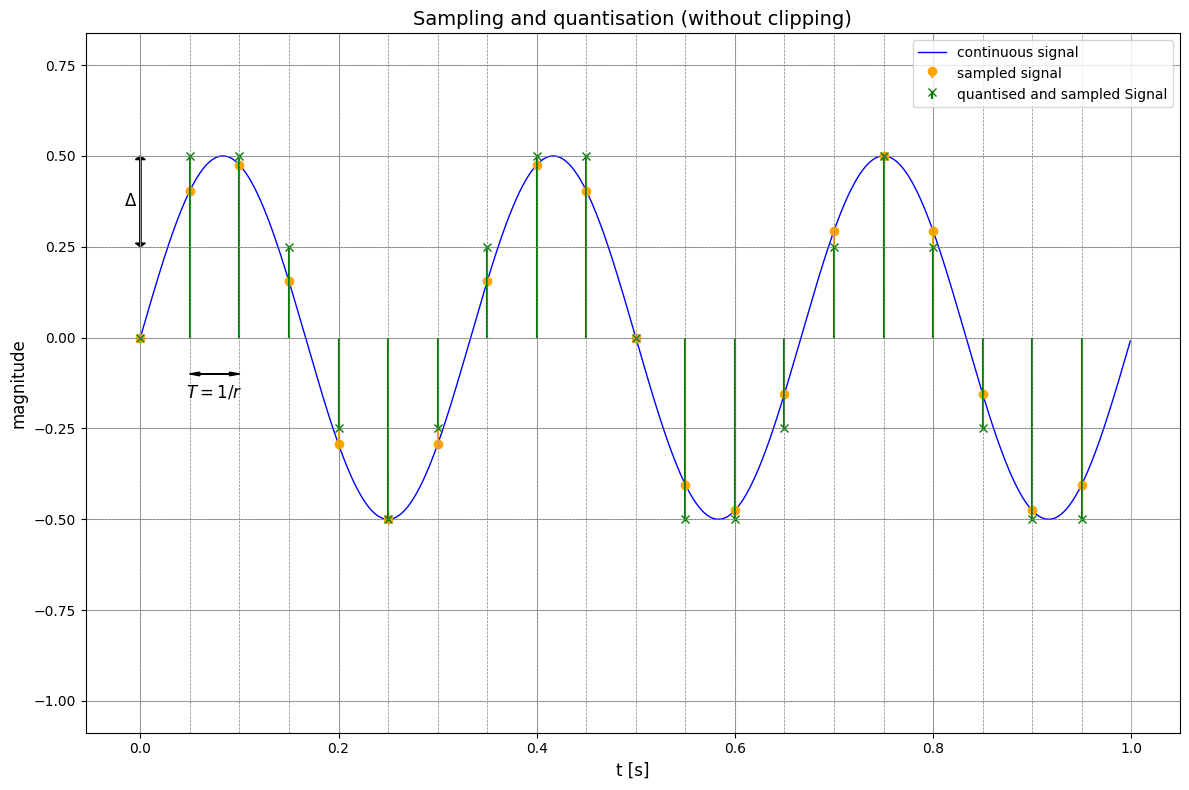

In [53]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.insert(1, '../Basics')
import WaveFileHandling

def CreatePlot(A, fs_cont, t_cont, signal_cont, title="Sampling and quantisation (without clipping)"):
    r = 20  # low sampling rate for visualizing sampling and quantisation
    SamplingFactor = int(fs_cont / r)
    t_sampled = t_cont[::SamplingFactor]
    signal_sampled = signal_cont[::SamplingFactor]

    w = 3
    quantization_levels = 2**w  # Anzahl der Quantisierungsstufen
    delta = (2*A) / quantization_levels
    #signal_quantized = np.round(signal_sampled * (quantization_levels / 2)) / (quantization_levels / 2)
    signal_quantized = np.round(signal_sampled / delta)
    signal_quantized = np.minimum(signal_quantized, quantization_levels // 2 - 1)  # Clip to max level
    signal_quantized = np.maximum(signal_quantized, -quantization_levels // 2)  # Clip to min level
    signal_quantized = signal_quantized * delta

    plt.figure(figsize=(12, 8))
    plt.plot(t_cont, signal_cont, label="continuous signal", color="blue", linewidth=1)
    plt.stem(t_sampled, signal_sampled, linefmt="orange", markerfmt="o", basefmt=" ", label="sampled signal")
    plt.stem(t_sampled, signal_quantized, linefmt="green", markerfmt="x", basefmt=" ", label="quantised and sampled Signal")

    # mark all quantisation intervals
    for t in t_sampled:
        plt.axvline(x=t, color='gray', linestyle='--', linewidth=0.5)
    value = -A
    while value < A:
        plt.axhline(value, color='gray', linestyle='--', linewidth=0.5)
        value += delta

    # plot quantisation level Δ
    plt.arrow(0, delta, 0, delta, head_width=0.01, head_length=0.01, linewidth=1, color='k', length_includes_head=True)
    plt.arrow(0, 2*delta, 0, -delta, head_width=0.01, head_length=0.01, linewidth=1, color='k', length_includes_head=True)
    plt.text(-0.01, 1.5*delta, r"$\Delta$", ha="center", va="center", fontsize=12, color="black")
    # plotting of sampling rate and sampling duration
    plt.arrow(1/r, -0.1, 1/r, 0, head_width=0.01, head_length=0.01, linewidth=1, color='k', length_includes_head=True)
    plt.arrow(2/r, -0.1, -1/r, 0, head_width=0.01, head_length=0.01, linewidth=1, color='k', length_includes_head=True)
    plt.text(1.5/r, -0.15, r"$T=1/r$", ha="center", va="center", fontsize=12, color="black")

    plt.title(title, fontsize=14)
    plt.xlabel("t [s]", fontsize=12)
    plt.ylabel("magnitude", fontsize=12)
    plt.legend(fontsize=10)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

A = 1.0  # overload point
f = 3  # frequency of the sinusoidal signal
fs_cont = 1000  # high sampling rate for continuous signal
t_cont = np.linspace(0, 1, fs_cont, endpoint=False)
signal_cont = 0.5*A*np.sin(2 * np.pi * f * t_cont)
CreatePlot(A, fs_cont, t_cont, signal_cont)


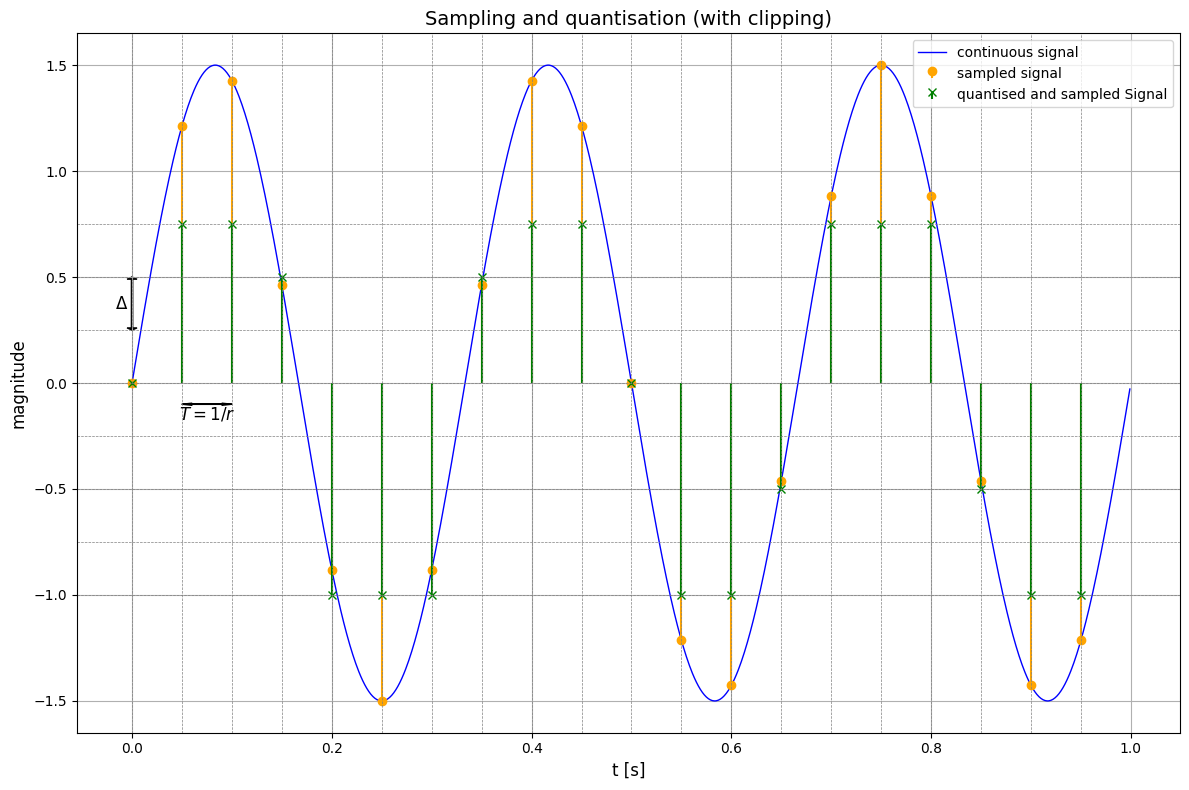

In [54]:
signal_cont = 1.5*A*np.sin(2 * np.pi * f * t_cont)
CreatePlot(A, fs_cont, t_cont, signal_cont, title="Sampling and quantisation (with clipping)")

## Auralisation
In the following audio examples for quantisation with different parameters $w$ and audio examples for clipping are created in order to show the results of these effects.

In [55]:
A = 1.0
WaveSamples, WaveSamplingRate = WaveFileHandling.ReadWaveAsNumpyArray('../Audio/P501_D_EN_fm_SWB_48k.wav')
WaveSamples *= A / np.amax(np.abs(WaveSamples)) # normalising to maximum possible level
WaveFileHandling.WriteWaveAsNumpyArray(WaveSamples, WaveSamplingRate, 'original.wav')
### apply clipping
NewOverloadpoint = 0.3*A
OutputSamples = np.maximum(WaveSamples, -NewOverloadpoint)
OutputSamples = np.minimum(OutputSamples, NewOverloadpoint)
WaveFileHandling.WriteWaveAsNumpyArray(OutputSamples, WaveSamplingRate, 'clipping.wav')
### apply quantisation
w = 4
quantization_levels = 2**w  # Anzahl der Quantisierungsstufen
delta = (2*A) / quantization_levels
OutputSamples = np.round(WaveSamples / delta)
OutputSamples = np.minimum(OutputSamples, quantization_levels // 2 - 1)  # Clip to max level
OutputSamples = np.maximum(OutputSamples, -quantization_levels // 2)  # Clip to min level
OutputSamples = OutputSamples * delta
WaveFileHandling.WriteWaveAsNumpyArray(OutputSamples, WaveSamplingRate, 'quantised_' + str(w) + 'Bits.wav')

## Sampling Theorem

The sampling theorem states, that the highest frequency $f_c$ of the time-continuous signal $x(t)$ must be lower or equal than half of the samplerate:

$f_c \leq \frac{1}{2T} = \frac{r}{2}$

In the following, a sinus is sampled without violating the sampling theorem.

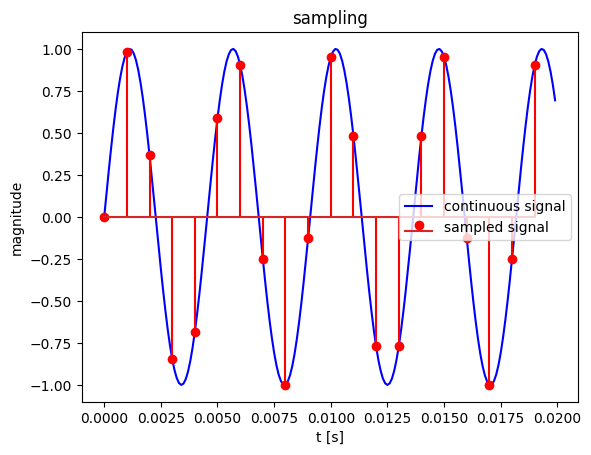

In [56]:
def TimeContinuousFunction(t, FrequencyInHertz = 220):
    return np.sin(2*np.pi*FrequencyInHertz*t)

def InterpolationFilter(x):
    return np.sinc(x)

def ReconstructedSignal(s_a, t, r, InterpolationFilterFunctionPointer = InterpolationFilter):
    s_tilde = np.zeros(t.shape)
    for n in range(s_a.shape[0]):
        h = InterpolationFilterFunctionPointer(t*r - n)
        s_tilde += s_a[n] * h
    return s_tilde

r = 1000 # samplerate in Hertz
UpsamplingFactor = 10
t = np.arange(200)/(UpsamplingFactor*r) # simulation of time continuous function by ten times faster sampling
s = TimeContinuousFunction(t)

t_a = t[0::UpsamplingFactor]
s_a = TimeContinuousFunction(t_a)

plt.plot(t  , s  , 'b', label='continuous signal')
plt.stem(t_a, s_a, 'r', label='sampled signal')
plt.xlabel('t [s]')
plt.ylabel('magnitude')
plt.title('sampling')
plt.legend()
plt.show()

## Reconstruction by lowpass
The reconstruction of the continuous signal out of a sampled signal corresponds to a smooth connection of the sampling values. A smooth connection corresponds to a lowpass. For audio purposes, the [sinc](../Basics/Sinc.ipynb)-function can be used as a lowpass filter for reconstruction:

For every sample $n$ in the sampled signal, one instance of the sinc-function is multiplied with the magnitude $x(n)$ at this position $n$. The center of this sinc-function is shifted to the position of the sampled value $n\cdot T$.
For reconstruction purposes, all of these scaled and shifted sinc-functions are added up, forming the dashed black line.

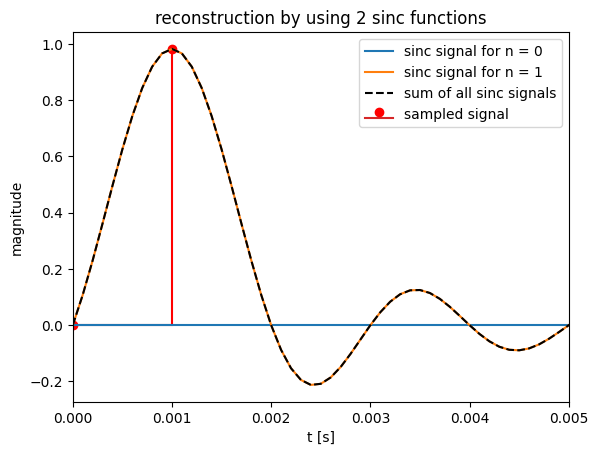

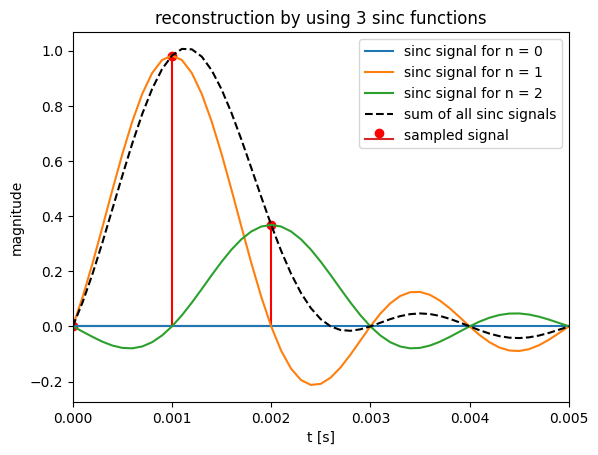

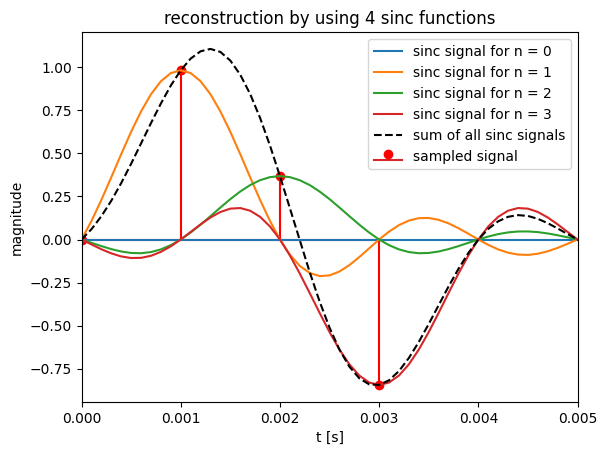

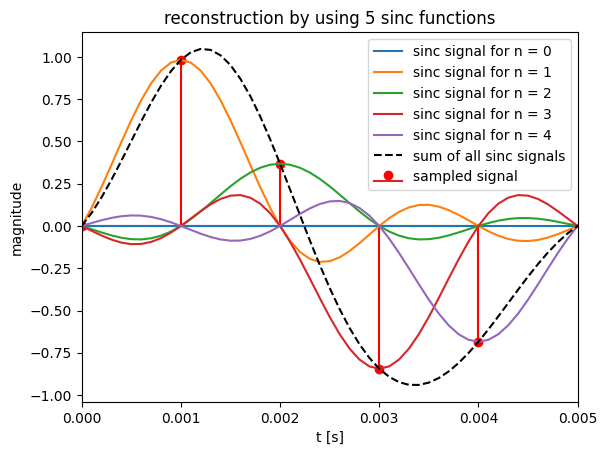

In [57]:
# deomonstrate the reconstruction by a lowpass with the first three sinc functions as impulse response
for Limit in range(2, 6):
    plt.stem(t_a[:Limit], s_a[:Limit], 'r', label='sampled signal')
    for n in range(Limit):
        h = InterpolationFilter(t*r - n)
        plt.plot(t, s_a[n] * h, label='sinc signal for n = ' + str(n))
    plt.plot(t, ReconstructedSignal(s_a[:Limit], t, r), '--k', label='sum of all sinc signals')
    plt.xlabel('t [s]')
    plt.ylabel('magnitude')
    plt.xlim(0, 0.005)
    plt.title('reconstruction by using ' + str(Limit) + ' sinc functions')
    plt.legend()
    plt.show()


## Reconstruction
The result of the reconstruction of the time continuous signal out of the sampled signal is shown in the following. Due to the usage of the ideal lowpass (aka [sinc](../Basics/Sinc.ipynb)-function), the reconstruction in the middle of the time axis is perfect, with no differences between the blue and the dashed black line.

Due to the infinite length of the sinc-function the reconstruction is not perfect at the beginning and the ending of the time axis.

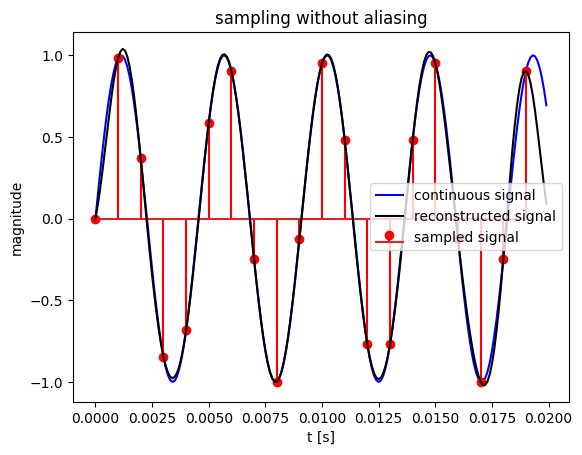

In [58]:
plt.plot(t  , s  , 'b', label='continuous signal')
plt.stem(t_a, s_a, 'r', label='sampled signal')
plt.plot(t, ReconstructedSignal(s_a, t, r), '--k', label='reconstructed signal')
plt.xlabel('t [s]')
plt.ylabel('magnitude')
plt.title('sampling without aliasing')
plt.legend()
plt.show()

## Alias
If the sampling theorem is violated, the resulting error is called alias. Alias basically means 'reconstruction with wrong frequency'.

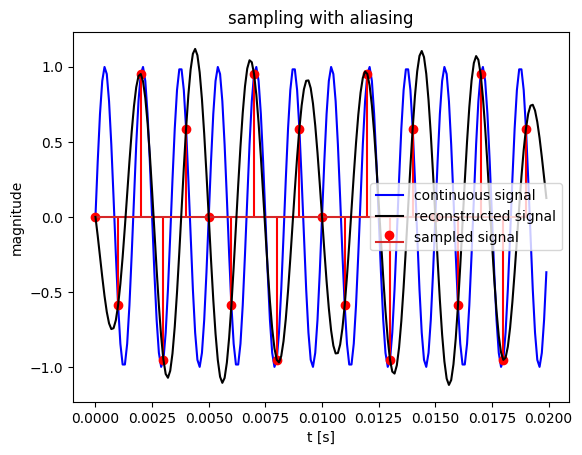

In [59]:
FrequencyInHertz = 600
t = np.arange(200)/(UpsamplingFactor*r)
s = TimeContinuousFunction(t, FrequencyInHertz)
s_a = TimeContinuousFunction(t_a, FrequencyInHertz)
plt.plot(t  , s  , 'b', label='continuous signal')
plt.stem(t_a, s_a, 'r', label='sampled signal')
plt.plot(t, ReconstructedSignal(s_a, t, r), 'k', label='reconstructed signal')
plt.xlabel('t [s]')
plt.ylabel('magnitude')
plt.title('sampling with aliasing')
plt.legend()
plt.show()

## Downsampling
The sampling theorem states, that the following condition must be met, if alias should be avoided:

$f_c \leq \frac{1}{2T}$

In the following, we assume that the highest frequency $f_c$ of a signal $x(n)$ is much less than half of the sampling rate:

$f_c \ll \frac{1}{2T}$ 

In this case, it is possible to reduce the sampling rate $r=\frac{1}{T}$ by a factor $N$:

$N\cdot f_c \leq \frac{1}{2T}$

$\rightarrow N\leq \frac{1}{2Tf_c}=\frac{r}{2f_c}$

This reducing of sampling rate is called downsampling. If $N$ is an integer value, the downsampling is a very simple algorithm:

$x_\text{downsampled}(n)=x\left(N\cdot n\right)$

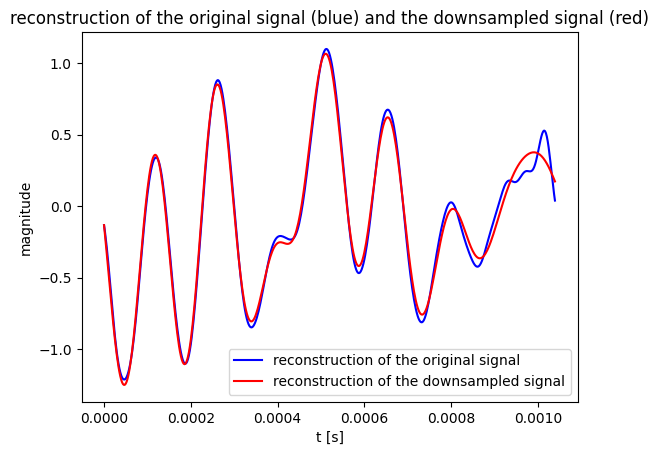

SNR =  20.276228180217785  dB


In [60]:
r = 48000
x = np.random.randn(50)
fc = 8000
t = np.arange(x.shape[0]) / r
y = np.zeros(x.shape)
for n in range(x.shape[0]):    
    y += x[n] * np.sinc(2*fc*(t - n/r)) * 2 * fc / r

N = 10
t = np.arange(y.shape[0] * N) / (r*N)
z1 = ReconstructedSignal(y, t, r)
DownSamplingFactor = r // (2*fc)

y_Downsampled = y[0::DownSamplingFactor]
z2 = ReconstructedSignal(y_Downsampled, t, r / DownSamplingFactor)
plt.plot(t, z1, 'b', label='reconstruction of the original signal')
plt.plot(t, z2, 'r', label='reconstruction of the downsampled signal')
plt.title('reconstruction of the original signal (blue) and the downsampled signal (red)')
plt.legend()
plt.xlabel('t [s]')
plt.ylabel('magnitude')
plt.show()
SNR = 10*np.log10(np.sum(z1**2) / np.sum((z1-z2)**2))
print('SNR = ', SNR, ' dB')

## Logarithmic level

In the following, two logarithmic levels are introduced, the dB SPL of the analogue world referencing to physical sound pressure and the dB FS of the digital world referencing to the overload point.

### dB Sound pressure level

The human ear can analyse a wide range of sound pressure. Therefore, soundlevel is usually described as a logarithmic value, e.g. [dB](../Basics/Decibel.ipynb) SPL (Sound pressure level):

$L=20\log_{10}\frac{p_\text{eff}}{20\mu\text{Pa}}$ dB SPL

with $p_\text{eff}$ corresponding to the [RMS](../Basics/RootMeanSquare.ipynb) of the sound pressure.
$0$ dB SPL corresponds to a silent sleeping room, where nothing can be heard. $140$ dB SPL is a starting jet.

### dB Full Scale
dB FS is normalized to the maximum possible amplitude of a digital signal. Assuming the maximum possible magnitude is $A$ (usually, $A$ corresponds to the overload point in digital domain). A sinus with the magnitude $A$ has a [RMS](../Basics/RootMeanSquare.ipynb) of $\frac{A}{\sqrt{2}}$ and a [power](../Basics/Power.ipynb) of $P=\frac{A^2}{2}$. This sinus is defined as $0$ dB FS. An arbitrary signal $x(n)$ with a power of

$P=\frac{1}{N}\sum_{n=0}^{N-1}x^2(n)$

has a [level](../Basics/Decibel.ipynb) of

$L=10\log_{10}\frac{P}{\frac{A^2}{2}}\text{ dB FS}=10\log_{10}\frac{2\cdot P}{A^2}\text{ dB FS}$

The digital output of a AD converter is usually normalized to a maximum possible magnitude of $A=1$.

### Calibration

Calibration can be done by the measurement of dB SPL in physical domain and dB FS in digital domain of the same signal. The calibration can be defined by a parameter $a$:

$L_\text{dB FS} = a + L_\text{dB SPL}$

E.g. the teachers Smartphone has a calibration factor of $a\approx -115$ dB (measured in January 2023).

## Quantisation noise

Digital values are stored with a certain resolution due to quantisation of the samples. This quantisation corresponds on the lowest level to a rounding of continuous values to discrete magnitudes with a resolution of $w$ bits. This rounding can be interpreted as additional noise in the recording if three conditions are fullfilled:

1) The signal has a power much higher than the power of the quantisation noise.
2) The signal frequency is high enough, such that neighbouring magnitudes has uncorrelated quantisation noise and
3) the signal is not periodic with a period-length $T_0=\frac{n}{r}$, with $n$ being an integer.

- For condition 1), the sensitivity of the sensor should be high enough, such that the signal is recorded at a reasonable level in dB FS.
- Condition 2) is for audio not really a problem, because frequencies below roughly $16$ Hz are unhearable for humans. These very low frequencies can therefore be filtered out without any information loss for humans.
- Condition 3) is only a problem for artificial test signals (e.g. a 1 KHz signal). In normal recording situations, the input signal has a wide range of frequencies.

If the conditions 1) to 3) are fullfilled, the quantisation noise for $w$ Bits can be interpreted as white noise with a uniform distribution between $-\frac{\Delta}{2}$ and $\frac{\Delta}{2}$. The power of the quantisation noise is

$P_E=\frac{\Delta^2}{12}$

with

$\Delta=\frac{2A}{2^w}$

## Dithering
If at least one of the three conditions for the white noise assumption of quantisation noise is not fullfilled, dithering should be applied to the digital signal after analogue digital conversion. If you are unsure, whether all three conditions are fullfilled or not, apply dithering for safety reasons.

Dithering adds random noise at the level of the lowest bit to the signal.
By this, the quantisation noise becomes white again.

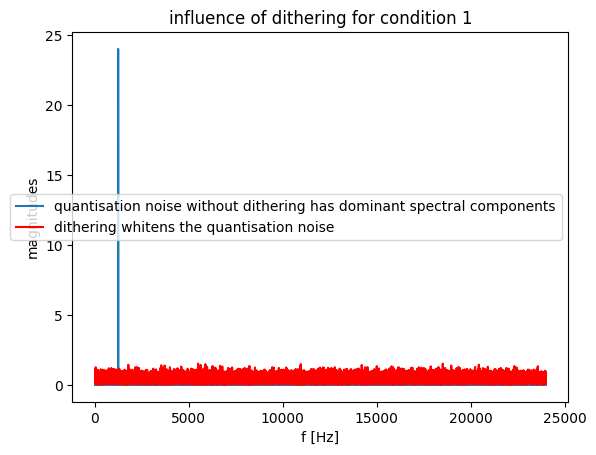

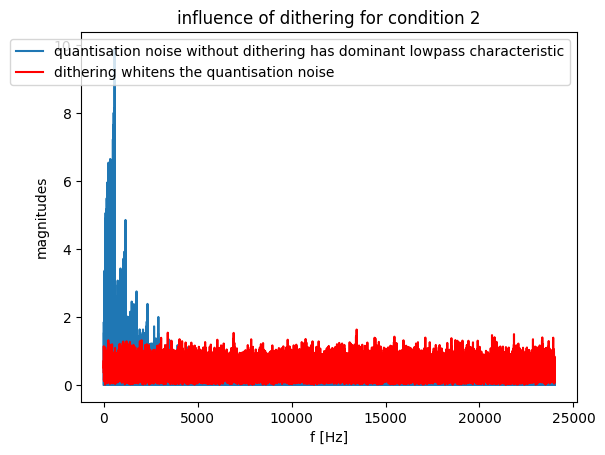

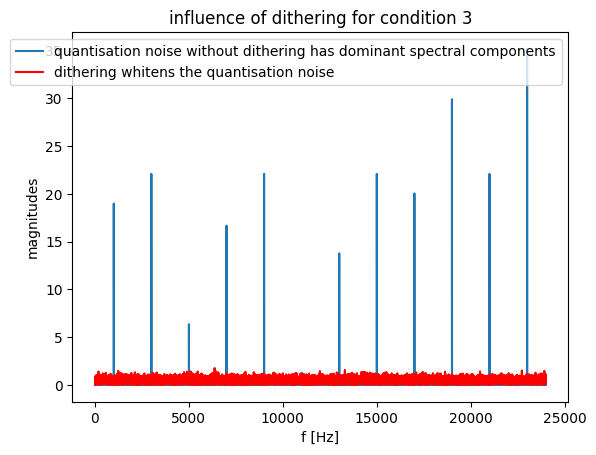

In [61]:
r = 48000
w = 8
A = 1.0
factor = 2**w / (2*A)

def ApplyQuantisation(x):
    return np.round(x * factor) / factor

def AddDithering(x):
    DitheringNoise = (np.random.rand(x.shape[0]) - 0.5) / factor # dithering noise at the lowest bit
    return x + DitheringNoise

def CreateSignals(magnitude, Frequency):
    t = np.arange(r) / r
    x = magnitude * np.sin(2*np.pi*Frequency*t) # periodic signal with a period length of 1/f, violating the condition 1)
    x_quantised = ApplyQuantisation(x)
    y = AddDithering(x_quantised)
    y_quantised = ApplyQuantisation(y)
    assert np.sum((x_quantised - y_quantised)**2) < 1e-2, 'additional error introduced by dithering'
    return x, x_quantised, y, y_quantised

def EvaluateSpectra(x, x_quantised, y, y_quantised):
    XQuantisationNoise = x_quantised - x
    YQuantisationNoise = y_quantised - y
    XQuantisationNoiseSpectrum = np.abs(np.fft.rfft(XQuantisationNoise))
    YQuantisationNoiseSpectrum = np.abs(np.fft.rfft(YQuantisationNoise))
    f_vector = np.arange(XQuantisationNoiseSpectrum.shape[0]) * r / XQuantisationNoise.shape[0]
    return f_vector, XQuantisationNoiseSpectrum, YQuantisationNoiseSpectrum

### demonstrate influence of condition 1
magnitude = A*1e-3
f = 1234
x, x_quantised, y, y_quantised = CreateSignals(magnitude, f)
f_vector, XQuantisationNoiseSpectrum, YQuantisationNoiseSpectrum = EvaluateSpectra(x, x_quantised, y, y_quantised)
plt.plot(f_vector, XQuantisationNoiseSpectrum, label='quantisation noise without dithering has dominant spectral components')
plt.plot(f_vector, YQuantisationNoiseSpectrum, 'r', label='dithering whitens the quantisation noise')
plt.xlabel('f [Hz]')
plt.ylabel('magnitudes')
plt.title('influence of dithering for condition 1')
plt.legend()
plt.show()

### demonstrate influence of condition 2
magnitude = np.random.rand(1) * A
f = 1
x, x_quantised, y, y_quantised = CreateSignals(magnitude, f)
f_vector, XQuantisationNoiseSpectrum, YQuantisationNoiseSpectrum = EvaluateSpectra(x, x_quantised, y, y_quantised)
plt.plot(f_vector, XQuantisationNoiseSpectrum, label='quantisation noise without dithering has dominant lowpass characteristic')
plt.plot(f_vector, YQuantisationNoiseSpectrum, 'r', label='dithering whitens the quantisation noise')
plt.xlabel('f [Hz]')
plt.ylabel('magnitudes')
plt.title('influence of dithering for condition 2')
plt.legend()
plt.show()

### demonstrate influence of condition 3
magnitude = np.random.rand(1) * A
f = 1000
x, x_quantised, y, y_quantised = CreateSignals(magnitude, f)
f_vector, XQuantisationNoiseSpectrum, YQuantisationNoiseSpectrum = EvaluateSpectra(x, x_quantised, y, y_quantised)
plt.plot(f_vector, XQuantisationNoiseSpectrum, label='quantisation noise without dithering has dominant spectral components')
plt.plot(f_vector, YQuantisationNoiseSpectrum, 'r', label='dithering whitens the quantisation noise')
plt.xlabel('f [Hz]')
plt.ylabel('magnitudes')
plt.title('influence of dithering for condition 3')
plt.legend()
plt.show()

## Programming exercise:

Fill in the missing code in the following procedures:

1) EvaluatePowerOfSignal

2) EvaluateSNROfQuantization

3) EvaluateSNR

4) EvaluatedBFullScale

5) EvaluatedBSoundPressureLevel

In [62]:
import unittest

def EvaluatePowerOfSignal(x):
    P_S = np.mean(x**2) # part of solution
    return P_S

def EvaluateSNROfQuantization(w):
    A = 1.0
    x = np.random.rand(10000) * 2 * A - A
    P_N = ((2*A) / (2**w))**2 / 12 # part of solution
    P_S = EvaluatePowerOfSignal(x) # part of solution
    SNR = 10*np.log10(P_S / P_N)
    return SNR

def EvaluateSNR(x, y):
    P_S = EvaluatePowerOfSignal(x) # part of solution
    P_N = EvaluatePowerOfSignal(x-y) # part of solution
    SNR = 10*np.log10(P_S / P_N) # part of solution
    return SNR

def EvaluatedBFullScale(A, x):
    L_dBFS = 10*np.log10(2*EvaluatePowerOfSignal(x) / (A**2)) # part of solution
    return L_dBFS

def EvaluatedBSoundPressureLevel(x_inPascal):
    L_SPL = 20*np.log10(np.sqrt(EvaluatePowerOfSignal(x_inPascal)) / (20e-6)) # part of solution
    return L_SPL

class TestProgrammingExercise(unittest.TestCase):

    def test_SNRMonotonicallyIncreasing(self):
        w1 = np.random.randint(20)
        w2 = w1 + 1
        self.assertGreater(EvaluateSNROfQuantization(w2), EvaluateSNROfQuantization(w1))
    
    def test_SNRSlope(self):
        for w in range(16):
            self.assertAlmostEqual(EvaluateSNROfQuantization(w), w*6, delta = 0.5)
            
    def test_EvaluatedBFullScale(self):
        A = np.random.rand(1)
        x = A*np.sin(2*np.pi*440*np.arange(10000)/16000)
        self.assertAlmostEqual(EvaluatedBFullScale(A, x), 0.0, delta = 0.5)
        self.assertAlmostEqual(EvaluatedBFullScale(A, x/np.sqrt(2)), -3.0, delta = 0.5)
        
    def test_EvaluatedBSoundPressureLevel(self):
        a = np.random.rand(1)
        x_inPascal = a*np.sin(2*np.pi*440*np.arange(10000)/16000)
        self.assertAlmostEqual(EvaluatedBSoundPressureLevel(x_inPascal), 20*np.log10(a) + 90.969, delta = 0.5)
        
    def test_EvaluatePowerOfSignalSinus(self):
        A = np.random.rand(1)
        x = A*np.sin(2*np.pi*440*np.arange(10000)/16000)
        self.assertAlmostEqual(EvaluatePowerOfSignal(x), A**2/2, delta = 0.01)

    def test_EvaluatePowerOfSignalUniformNoise(self):
        A = np.random.rand(1)
        x = 2*A*np.random.rand(10000)-A
        self.assertAlmostEqual(EvaluatePowerOfSignal(x), (2*A)**2/12, delta = 0.01)
        
    def test_EvaluatePowerOfSignalGaussianNoise(self):
        s = np.random.rand(1)
        x = s*np.random.randn(10000)
        self.assertAlmostEqual(EvaluatePowerOfSignal(x), s**2, delta = 0.1)
        
    def test_EvaluateSNRErrorEqualSignal(self):
        x = np.random.randn(10000)
        e = np.random.randn(10000)
        y = x + e
        self.assertAlmostEqual(EvaluateSNR(x, y), 0.0, delta = 0.5)
        
    def test_EvaluateSNRSmallError(self):
        factor = 1e-3
        x = np.random.randn(10000)
        e = np.random.randn(10000) * factor
        y = x + e
        self.assertAlmostEqual(EvaluateSNR(x, y), -20*np.log10(factor), delta = 3.0)

# https://stackoverflow.com/questions/40172281/unit-tests-for-functions-in-a-jupyter-notebook
unittest.main(argv=[''], verbosity=2, exit=False)

test_EvaluatePowerOfSignalGaussianNoise (__main__.TestProgrammingExercise.test_EvaluatePowerOfSignalGaussianNoise) ... ok
test_EvaluatePowerOfSignalSinus (__main__.TestProgrammingExercise.test_EvaluatePowerOfSignalSinus) ... ok
test_EvaluatePowerOfSignalUniformNoise (__main__.TestProgrammingExercise.test_EvaluatePowerOfSignalUniformNoise) ... ok
test_EvaluateSNRErrorEqualSignal (__main__.TestProgrammingExercise.test_EvaluateSNRErrorEqualSignal) ... ok
test_EvaluateSNRSmallError (__main__.TestProgrammingExercise.test_EvaluateSNRSmallError) ... ok
test_EvaluatedBFullScale (__main__.TestProgrammingExercise.test_EvaluatedBFullScale) ... ok
test_EvaluatedBSoundPressureLevel (__main__.TestProgrammingExercise.test_EvaluatedBSoundPressureLevel) ... ok
test_SNRMonotonicallyIncreasing (__main__.TestProgrammingExercise.test_SNRMonotonicallyIncreasing) ... ok
test_SNRSlope (__main__.TestProgrammingExercise.test_SNRSlope) ... ok

---------------------------------------------------------------------

## Exam preparation

1) A quantizer with $w=16$ bit is used. Give the amount of data for 70 minutes of recording on an audio cd. Hint: Audio cd are recorded in stereo mode.

2) Evaluate the level in dB SPL of a sinus with a magnitude of $0.1$ Pa. This sinus is digitalized to a digital signal $x(n)=0.25\cdot\sin\left(2\pi f\frac{n}{r}\right)$. The maximum possible magnitude of this AD converter is $A=1.0$. Evaluate the corresponding level dB FS and the calibration factor $a$.

3) Evaluate the SNR for a signal with $-12$ dB FS with quantization noise for $w=16$ bit. $A=1.0$ is still valid.

4) A signal $x(t)=a\cdot\cos\left(2\pi ft\right)$ is given, with $f=2$ kHz. $x(t)$ has a level of $75$ dB SPL. Evaluate the parameter $a$. Is it possible to evaluate the sign of $a$ by the given informations? Evaluate the level in dB SPL if the frequency is doubled.

5) What kind of function $y=f(x)$ results in a linear plot for a logarithmic x-axis, for a logarithmic y-axis and for a double-logarithmic plot?

6) A signal has a calibration factor of $a=-120$ dB. Evaluate the Overload Point in dB SPL. Assume the signal to be a sinus.

7) Evaluate the level in dB FS of the quantisation noise for $w=16$ Bits.

8) Give the mathematical description of a digital signal, which corresponds to the highest possible level in dB FS. What is the corresponding level in dB FS?

9) A time continuous signal $x(t)=\cos\left(7\cdot t\right)^2$ is sampled by $r=10$ Hz. Evaluate the first five samples.

10) A time discrete signal sampled with $r=32$ kHz is filtered by a lowpass with a cutoff frequency of $f_c=3400$ Hz. What is the lowest necessary sampling frequency after the lowpass. What is the maximum allowed integer downsampling factor? Corresponds the signal after the lowpass to wideband speech or to narrowband speech?

11) A microfone signal $y(n)$ is recorded with $r=48$ kHz. Afterwards, $y(n)$ is filtered by a bandpass $h(n)$ with cutoff frequencies $f_1=100$ Hz and $f_2=7000$ Hz: $z(n)=h(n)*y(n)$. Does $z(n)$ has a DC component? Are human voices understandable in $z(n)$? What are the highest frequencies in $y(n)$ and $z(n)$?

12) A signal $𝑥(𝑡)=\cos⁡(500\cdot 𝑡)$ is sampled with $𝑟=200$ Hz. Does this sampling cause alias? 

## Summary
After working with this Jupyter Notebook you should be able to explain the following topics:

- In which cases is the overload point $A$ relevant for your measurement?
- In which case is the number of bits $w$ relevant for your measurement?
- In which case is the sampling rate $r$ relevant for your measurement?
- What is the sampling theorem?
- What is aliasing?
- What are the difference between dB SPL and dB FS?
- When do you want to implement dithering?
- How does the quantisation noise affects your measurement?